# Generate zonal wind profiles in the same was as generateZWP using the cylindrical maps, exclusively. Functions are now fully defined in zonalwindfunctions.py as ZWP_Class

In [1]:
import planetmapper
from planetmapper.kernel_downloader import download_urls
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import pytz
import datetime
import csv
import os
import pandas as pd

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class

# print(matplotlib.get_backend())

In [2]:
# longitutde array is defined relative to the West, which is how all maps are projected for this project.
long_res, lat_res = 360, 180
long_res_hi, lat_res_hi = 720, 360
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
long_array_hi, lat_array_hi = np.linspace(360, 0,long_res_hi), np.linspace(-90, 90,lat_res_hi)

one_J_day = 9.9258 # hours
variation = 51/60 # hrs
R_J = 71492e3 # m
R_J_p = 66854e3 # m

oblateness = (R_J - R_J_p) / R_J # Jupiter oblateness
print(oblateness)
print(2*np.pi*R_J, one_J_day*3600, (variation/one_J_day)*180/np.pi)

print(R_J*(1 - oblateness*np.sin(lat_array*np.pi/180)**2)[89])

0.0648743915403122
449197483.980883 35732.880000000005 4.9065478436115955
71491642.84783395


In [4]:
'''
Load data from file to get the correct file list
'''

# Update if need be but try to keep things where they are. execution_path is the directory in which /prvt/ exists.
execution_path = '/Users/ahyder/Desktop/windfieldproject'

# Load from a CSV file
year = "2018"
main_path = 'spex/post_invigilation/'
cmap_files_paths_list_51 = [] # with threshold set to 51 min (0.85)
t_diff_list_cmap_51 = []

with open(main_path+f"PI_{year}.csv", "r") as f:
    reader = csv.reader(f)
    counter = 0
    for row in reader:
        selected_pair, t_diff_of_pair = [row[0], row[1]], float(row[2])
        t_diff_list_cmap_51.append(t_diff_of_pair)
        cmap_files_paths_list_51.append([selected_pair[0], selected_pair[1]])
        print(counter, selected_pair, t_diff_of_pair)
        counter += 1


'''
Super important index list! It is necessary for compatiblity of the maps.
0 - pair is already compatible.
1 - first map has a higher resolution and needs to be unresolved.
2 - second map has a higher resolution and needs to be unresolved.
'''

date_meta_list = []
smart_index_list = np.zeros(len(cmap_files_paths_list_51))
for i_f, f in enumerate(cmap_files_paths_list_51):
    hdul0 = fits.open(execution_path+f[0])
    hdul1 = fits.open(execution_path+f[1])
    d_t_0 = str(hdul0[0].header['DATE_OBS'] + 'T' + hdul0[0].header['TIME_OBS'])
    d_t_1 = str(hdul1[0].header['DATE_OBS'] + 'T' + hdul1[0].header['TIME_OBS'])
    date_meta_list.append([d_t_0, d_t_1])
    print(f[0].split('spex/')[-1], f[1].split('spex/')[-1])
    smart_index_list[i_f] = ZWP_Class.checkMapResolution(hdul0[0].data, hdul1[0].data)
    hdul0.close()
    hdul1.close()

compatible_map_pairs = ZWP_Class.makeMapsCompatible(cmap_files_paths_list_51, smart_index_list, emission_angle_correction=True, execution_path_bool=True, fits_str='.mu.gz') # defaults to fits_str='.mu.fits.gz'

print(smart_index_list)
for i in range(len(compatible_map_pairs)):
    print(i, compatible_map_pairs[i][0].shape, compatible_map_pairs[i][1].shape, int(smart_index_list[i]), date_meta_list[i])

print()
print(f'Total of {len(smart_index_list)} pairs to work through...')


0 ['/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz', '/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0017500209.cmap.gz'] 19.735724824722222
1 ['/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz', '/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0000100018.cmap.gz'] 19.178036294166667
2 ['/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0129101339.cmap.gz', '/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0004900083.cmap.gz'] 19.32877929722222
3 ['/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz', '/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0017500209.cmap.gz'] 19.607294919166666
4 ['/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz', '/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0000100018.cmap.gz'] 19.049606388611114
5 ['/prvt/cirs12/spex/2018jul20/5.10/jupiter/jcf0137501379.cmap.gz', '/prvt/cirs12/spex/2018jul21/5.10/jupiter/jcf0004900083.cmap.gz'] 19.200349391666666
2018jul20/5.10/jupiter/jcf0129101339.cmap.gz 2018jul21/5.10/jupiter/jcf001750

In [5]:
# for i_f, f in enumerate(cmap_files_paths_list_51):
#     print(ZWP_Class.getTemporalDifference(f), np.round(t_diff_list_cmap_51[i_f]*3600))

In [6]:
# final_longitudes_masked_shifted[152], final_longitudes_masked_shifted[461] # start and stop margins (after possible shift):  151 462
# print(final_longitudes_masked_shifted[146+1], final_longitudes_masked_shifted[286-1])
# print(final_longitudes_masked_shifted)

In [15]:
test_i             = 1    # index of the pair being correlated.
long_shift_applied = 90  # what is the shift that you want to apply, if need be.
margin_app         = 5    # how far you want to be from the NaNs. Sometimes needs to be lowered to 3 in the event that margin application fails.
window_length      = 45   # width of the sliding window.
window_stepping    = 1    # how many longitudes does the sliding take.
critical_lat       = 55   # the latitude where the correlation function stops applying.

# Rarely changed variables:
max_delta_longit   = 10   # how many ∆longitudes are permitted.
lat_res_tol        = 1e-2 # margin calculation threshold using critical latitude.

print(ZWP_Class.getSpeedatLat(max_delta_longit, lat_array, t_diff_list_cmap_51[test_i]*3600))

print('map shape: ', compatible_map_pairs[test_i][0].shape)
print()

if compatible_map_pairs[test_i][0].size > 180*360:
    lat_array_use  = lat_array_hi
    long_array_use = long_array_hi
else:
    lat_array_use  = lat_array
    long_array_use = long_array


_, _, _, _, _, corr_1D, corr_1D_coeff, error_array_slide, fwhm_array_slide = ZWP_Class.getFullLatitudinalCorrelation(
                            compatible_map_pairs[test_i][0], compatible_map_pairs[test_i][1], 
                            long_array_use, lat_array_use, shift_long=long_shift_applied, crit_lat=critical_lat, 
                            margin=margin_app, max_delta_long=max_delta_longit, force_shift=False, sliding_window_boolean=True, sliding_window_len=window_length, window_step=window_stepping, lat_res_tol=lat_res_tol)
print()
shifted_f1, shifted_f2, shifted_BIM, margin_applied_in_func_shifted, final_longitudes_masked_shifted, corr_1D_noshift, corr_1D_coeff_noshift, error_array, fwhm_array = ZWP_Class.getFullLatitudinalCorrelation(
                            compatible_map_pairs[test_i][0], compatible_map_pairs[test_i][1], 
                            long_array_use, lat_array_use, shift_long=long_shift_applied, crit_lat=critical_lat, 
                            margin=margin_app, max_delta_long=max_delta_longit, force_shift=False, sliding_window_boolean=False, sliding_window_len=window_length, window_step=window_stepping, lat_res_tol=lat_res_tol)

# due to shift, the x-axis is technically wrapped so plotting the margins must be done with the appropriate wrapping commands:
# print(long_array[20]+90-360, long_array[232]+90)

# plt.contourf(long_array, lat_array, shifted_BIM)
# plt.gca().invert_xaxis()
# # plt.vlines(long_array[146], -90, 90), plt.vlines(long_array[286], -90, 90)
# # plt.colorbar()
# plt.show()

# print(final_longitudes_masked_shifted)

[169.00444519 169.00805638 169.01888551 169.03691923 169.06213532
 169.09450273 169.13398157 169.1805232  169.23407029 169.29455687
 169.36190842 169.43604195 169.51686615 169.60428142 169.69818009
 169.79844646 169.90495701 170.01758052 170.13617823 170.26060404
 170.39070465 170.52631978 170.66728234 170.81341869 170.96454877
 171.1204864  171.28103945 171.44601014 171.61519521 171.78838624
 171.96536985 172.14592799 172.32983823 172.51687398 172.70680482
 172.89939676 173.09441251 173.29161183 173.49075176 173.69158697
 173.89387002 174.09735171 174.30178134 174.50690707 174.71247617
 174.91823539 175.12393122 175.32931027 175.53411949 175.73810657
 175.94102019 176.14261037 176.34262874 176.54082889 176.73696664
 176.93080033 177.12209118 177.31060351 177.49610507 177.67836733
 177.85716575 178.03228003 178.20349445 178.37059807 178.53338501
 178.69165473 178.84521223 178.99386834 179.13743991 179.27575006
 179.40862839 179.5359112  179.65744168 179.7730701  179.882654
 179.9860583

In [16]:
'''
Load some HST data for comparison and get the appropriate ∆t for the case currently being used.
'''

hst_wind_1D = np.genfromtxt('Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)[:]
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')
delta_t = t_diff_list_cmap_51[test_i]*3600

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))[:]


(360, 93) (360, 93)
(360,) (360,)


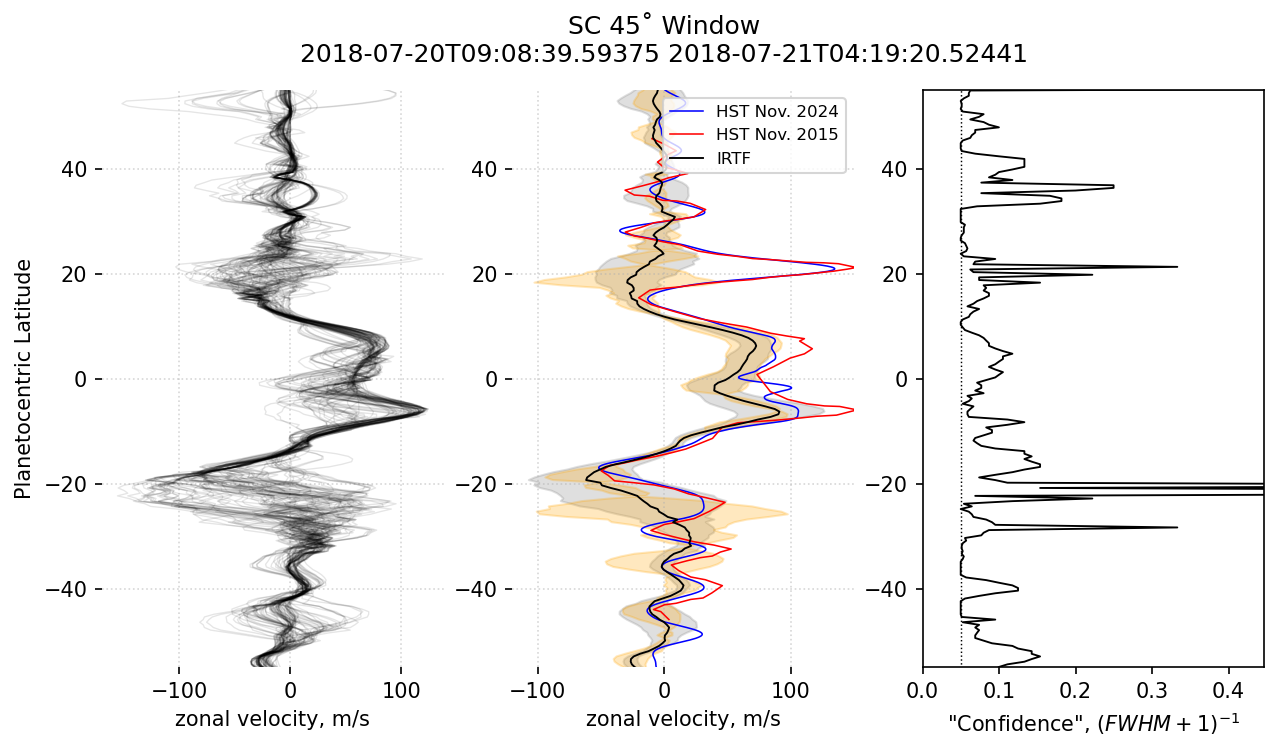

0.04993402319605172 0.44684951288693026


In [17]:
%matplotlib inline
print(corr_1D.shape, corr_1D_coeff.shape)
print(corr_1D_noshift.shape, corr_1D_coeff_noshift.shape)

smooth_wind_full = np.zeros_like(corr_1D)
rough_wind_full = np.zeros_like(corr_1D)

plt.figure(figsize=(10,5), dpi=150)
plt.subplot(131)
for c in range(corr_1D.shape[1]):
    rough_wind_full[:, c] = -ZWP_Class.getSpeedatLat(corr_1D[:, c], lat_array_use, delta_t)
    smooth_wind_full[:, c] = ZWP_Class.getSmoothedProfile(rough_wind_full[:, c], lat_array_use, jet_width=7, poly_order=3)
    plt.plot(smooth_wind_full[:, c], lat_array_use, color='k', lw=0.65, alpha=0.1)
    plt.ylim(-critical_lat, critical_lat)

plt.ylabel('Planetocentric Latitude'), plt.xlabel('zonal velocity, m/s')
plt.gca().set_frame_on(False)
plt.grid(True, 'both', ls=':', alpha=0.5)

# Either smooth before averaging or average before smoothing...
rough_wind_mean, rough_wind_std = np.mean(rough_wind_full, axis=1), np.std(rough_wind_full, axis=1)
smooth_wind_mean, smooth_wind_std = np.mean(smooth_wind_full, axis=1), np.std(smooth_wind_full, axis=1)
# smooth_wind_mean, smooth_wind_std = ZWP_Class.getSmoothedProfile(rough_wind_mean, lat_array_use, jet_width=7, poly_order=3), ZWP_Class.getSmoothedProfile(rough_wind_std, lat_array_use, jet_width=7, poly_order=3)


err_velocity_slide = -ZWP_Class.getSpeedatLat(error_array_slide, lat_array_use, delta_t) # correlation error bound for sliding window in m/s
smooth_err_velocity = ZWP_Class.getSmoothedProfile(err_velocity_slide, lat_array_use, jet_width=7, poly_order=3)
confidence_slide = 1/(fwhm_array_slide+1)


plt.subplot(132)
plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')
plt.plot(smooth_wind_mean, lat_array_use, color='k', lw=0.9, label='IRTF')
plt.fill_betweenx(lat_array_use, smooth_wind_mean-smooth_wind_std, smooth_wind_mean+smooth_wind_std, color='gray', alpha=0.25)
plt.fill_betweenx(lat_array_use, smooth_wind_mean-smooth_err_velocity, smooth_wind_mean+smooth_err_velocity, color='orange', alpha=0.25)
plt.ylim(-critical_lat, critical_lat)
plt.xlim(-120, 150)
plt.gca().set_frame_on(False)
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.xlabel('zonal velocity, m/s')
plt.legend(loc='upper right', fontsize=8)
# plt.suptitle('Sliding Correlations with 45˚ Window')
plt.suptitle(f'SC {window_length}˚ Window\n'+date_meta_list[test_i][0] + ' ' + date_meta_list[test_i][1])


plt.subplot(133)
plt.plot(confidence_slide, lat_array_use, color='k', lw=0.9)
# plt.vlines(0, np.min(lat_array_use), np.max(lat_array_use), color='k', lw=0.7, ls=':')
plt.vlines(np.min(confidence_slide), np.min(lat_array_use), np.max(lat_array_use), color='k', lw=0.7, ls=':')
plt.xlabel(r'"Confidence", $(FWHM+1)^{-1}$')
plt.xlim(0, np.mean(confidence_slide))
plt.ylim(-critical_lat, critical_lat)
plt.show()

print(np.min(confidence_slide), np.mean(confidence_slide))

In [9]:
pearson_thresh = 0.275
corr_1D_with_thresh = corr_1D_noshift
# for ic in range(len(corr_1D_coeff)):
#     if corr_1D_coeff[ic] < pearson_thresh:
#         corr_1D_with_thresh[ic] = np.nan
#     else:
#         pass
# print(corr_1D_with_thresh)
print(corr_1D_noshift.shape)

(360,)


In [10]:
print(compatible_map_pairs[test_i][1].shape)
print(corr_1D_coeff)
print(8/360 * 2*np.pi*R_J / 72328.609369)

(360, 720)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
138.01131250512663


360
69040.930659


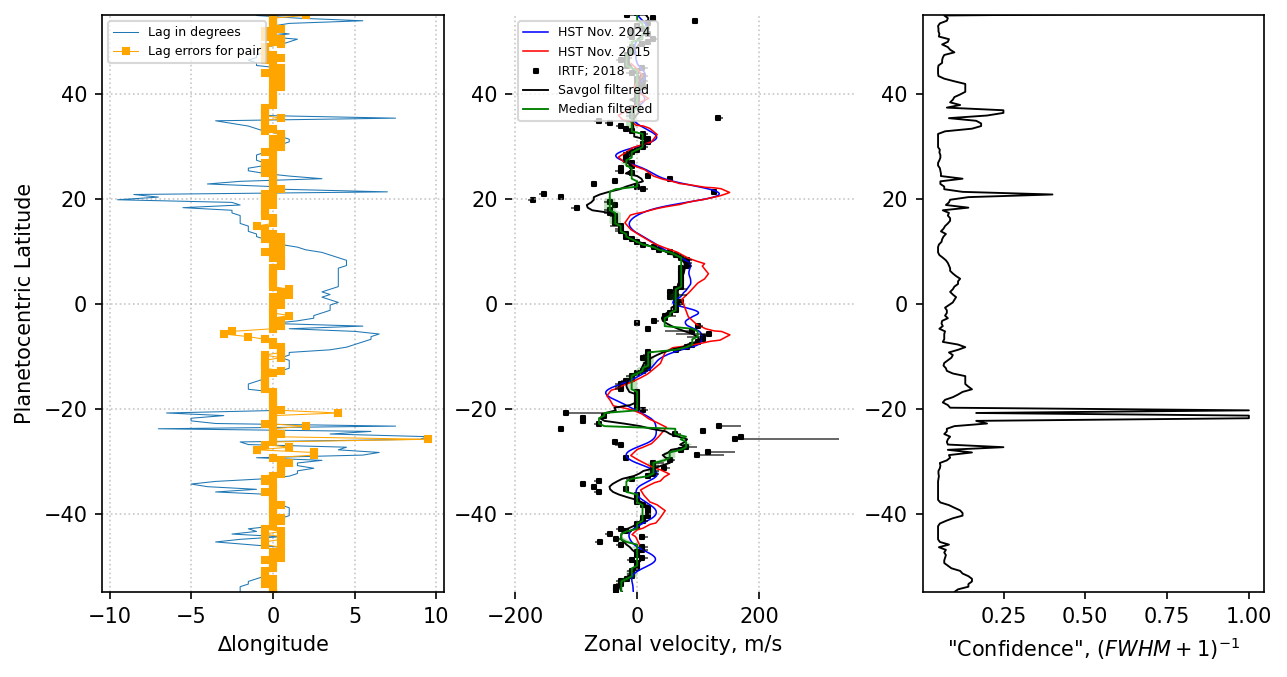

In [11]:

'''
For fullCorrelation() - NO SLIDING WINDOW USED OR AN AVERAGING HAS BEEN PERFORMED...
'''
zwp_5microns = -ZWP_Class.getSpeedatLat(corr_1D_with_thresh, lat_array_use, delta_t) # minus is necessary to match the other observations of the wind speed.
err_velocity = -ZWP_Class.getSpeedatLat(error_array, lat_array_use, delta_t) # correlation error bound in m/s

%matplotlib inline
y_lim_range = critical_lat #critical_lat - critical_lat*0.05 # -5% for aesthetics...
plt.figure(figsize=(10,5), dpi=150)

print(len(lat_array_use))
# Apply Savgol filter
smooth_zwp_5microns = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, jet_width=7, poly_order=3)
smooth_err_velocity = ZWP_Class.getSmoothedProfile(err_velocity, lat_array_use, jet_width=7, poly_order=3)
confidence = 1/(fwhm_array+1)

#Apply median filter
medfilt_zwp_5microns = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, filter_type='median', jet_width=4, poly_order=3)
medfilt_err_velocity = ZWP_Class.getSmoothedProfile(err_velocity, lat_array_use, filter_type='median', jet_width=4, poly_order=3)

plt.subplot(131)
plt.plot(-corr_1D_noshift, lat_array_use, lw=0.5, label='Lag in degrees')
plt.plot(-error_array, lat_array_use, marker='s', ms=3, color='orange', lw=0.5, label='Lag errors for pair')
plt.xlabel('∆longitude')
plt.ylabel('Planetocentric Latitude')
# plt.xlim(-1000, 1000)
plt.ylim(-critical_lat, critical_lat)
plt.legend(loc='upper left', framealpha=0.75, fontsize=6)
plt.grid(True, 'both', ls=':', alpha=0.7)

print(delta_t)

# test_var_array = np.array([5., 7.])
# test_var_array = np.array([3, 5])
# print(test_var_array)

plt.subplot(132)
plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')

for z in range(len(zwp_5microns)):
    plt.hlines(lat_array_use[z], min(zwp_5microns[z], zwp_5microns[z]+err_velocity[z]), max(zwp_5microns[z], zwp_5microns[z]+err_velocity[z]), colors='k', alpha=0.75, lw=0.75)
    # plt.hlines(lat_array_use[z], zwp_5microns[z]-err_velocity[z], zwp_5microns[z]+err_velocity[z], colors='k', alpha=0.75, lw=0.75)
plt.scatter(zwp_5microns, lat_array_use, marker='s', s=5, color='k', label='IRTF; '+str(year))

# plt.fill_betweenx(lat_array_use, smooth_zwp_5microns-smooth_err_velocity, smooth_zwp_5microns+smooth_err_velocity, lat_array_use, color='orange', lw=0.9, alpha=0.5)
plt.plot(smooth_zwp_5microns, lat_array_use, color='k', lw=0.9, label='Savgol filtered')
# plt.fill_betweenx(lat_array_use, zwp_5microns-err_velocity, zwp_5microns+err_velocity, lat_array_use, color='orange', lw=0.9, alpha=0.5)

plt.fill_betweenx(lat_array_use, medfilt_zwp_5microns-medfilt_err_velocity, medfilt_zwp_5microns+medfilt_err_velocity, lat_array_use, color='g', lw=0.1, alpha=0.25)
plt.plot(medfilt_zwp_5microns, lat_array_use, color='g', lw=0.9, label='Median filtered')

# for i in range(len(test_var_array)):
#     smooth_zwp_5microns_var = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, jet_width=7, poly_order=test_var_array[i])
#     plt.plot(smooth_zwp_5microns_var, lat_array_use, lw=0.5, label='jet 7')
plt.xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
plt.ylim(-critical_lat, critical_lat)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper left', framealpha=0.75, fontsize=6)

plt.gca().set_frame_on(False)

plt.subplot(133)
plt.plot(confidence, lat_array_use, color='k', lw=0.9)
plt.xlabel(r'"Confidence", $(FWHM+1)^{-1}$')
plt.ylim(-critical_lat, critical_lat)
plt.show()

In [13]:

print(zwp_5microns[150]+err_velocity[150], zwp_5microns[150])
print(max(zwp_5microns[150]+err_velocity[150], zwp_5microns[150]))

-0.0 -0.0
-0.0


In [14]:
print(opal_nov_2024_df['LAT'])
print(centric_lat_HST)

0      -90.0
1      -89.9
2      -89.8
3      -89.7
4      -89.6
        ... 
1795    89.5
1796    89.6
1797    89.7
1798    89.8
1799    89.9
Name: LAT, Length: 1800, dtype: float64
0      -90.000000
1      -89.885644
2      -89.771288
3      -89.656932
4      -89.542577
          ...    
1795    89.428223
1796    89.542577
1797    89.656932
1798    89.771288
1799    89.885644
Name: LAT, Length: 1800, dtype: float64


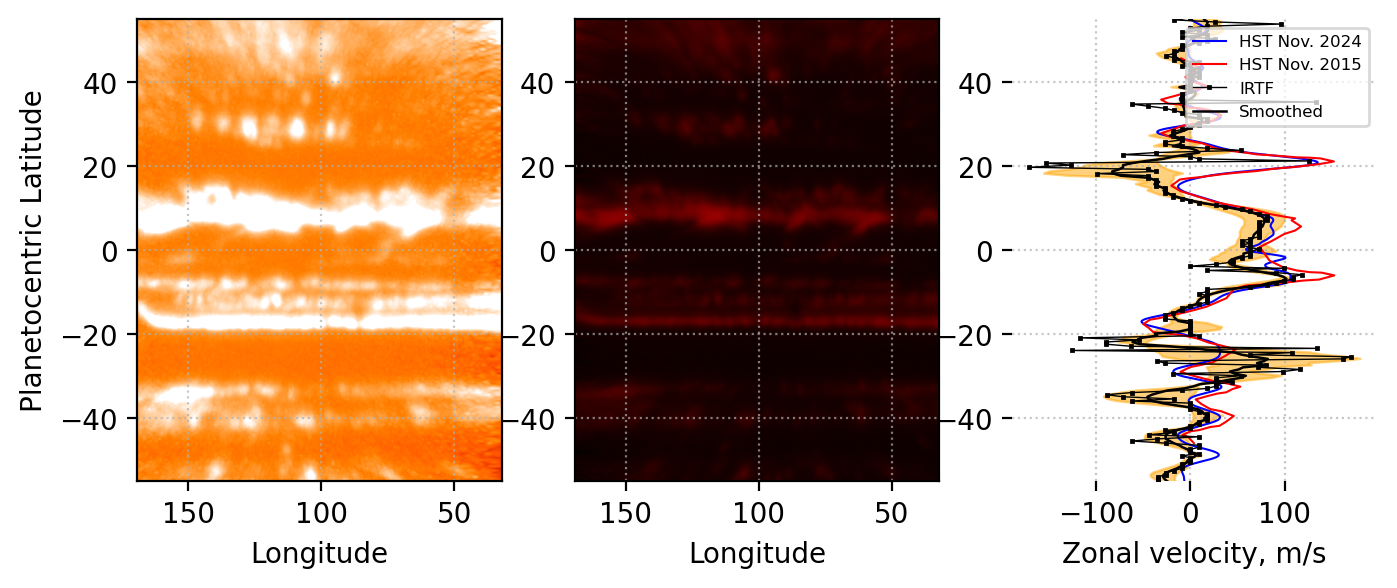

In [18]:
%matplotlib inline
colo = 'gist_heat'

# maps where things are defined...useful for analysis
heatmap1 = shifted_f1[:, margin_applied_in_func_shifted.astype(bool)]
heatmap2 = shifted_f2[:, margin_applied_in_func_shifted.astype(bool)]

plot1_upp, plot1_low = np.nanmax(heatmap1)/7e2, np.nanmin(heatmap1)
plot2_upp, plot2_low = np.nanmax(heatmap2)/4e2, np.nanmin(heatmap2)
plot1_range, plot2_range = np.linspace(plot1_low, plot1_upp, 256), np.linspace(plot2_low, plot2_upp, 256)

fig, axs = plt.subplots(
nrows=1, ncols=3, figsize=(8, 3), dpi=200)
axs[0].contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap1, plot1_range, cmap=colo)
# axs[0].contour(long_array[margin_applied_in_func_shifted.astype(bool)], lat_array, heatmap2, 128, cmap='bone', alpha=0.25)
axs[1].contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap2, plot2_range, cmap=colo)
axs[0].grid(True, 'both', ls=':', alpha=0.7), axs[1].grid(True, 'both', ls=':', alpha=0.7)
axs[0].set_ylim(-y_lim_range, y_lim_range), axs[1].set_ylim(-y_lim_range, y_lim_range)
axs[0].invert_xaxis(), axs[1].invert_xaxis()

# axs[2].plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', lw=0.5, label='HST 2015')
axs[2].plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')
axs[2].plot(zwp_5microns, lat_array_use, marker='s', ms=1, color='k', lw=0.5, label='IRTF')
axs[2].plot(smooth_zwp_5microns, lat_array_use, color='k', lw=0.9, label='Smoothed')
axs[2].fill_betweenx(lat_array_use, smooth_zwp_5microns-smooth_err_velocity, smooth_zwp_5microns+smooth_err_velocity, lat_array_use, color='orange', lw=0.9, alpha=0.5)
axs[2].set_xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
axs[2].set_ylim(-y_lim_range, y_lim_range)
axs[2].grid(True, 'both', ls=':', alpha=0.7)
axs[2].legend(loc='upper right', fontsize=6, framealpha=0.75)
axs[2].set_frame_on(False)


axs[0].set_ylabel('Planetocentric Latitude')
axs[0].set_xlabel('Longitude'), axs[1].set_xlabel('Longitude')

# sample_lat = [-3,-9, -11]
# colors_map = plt.get_cmap('plasma')(np.linspace(0., 0.75, len(sample_lat)))
# plt.figure(figsize=(8, 3), dpi=200)
# for i_sl, sl in enumerate(sample_lat):
#     # axs[0].hlines(sl, 100, 200, ls='dashed', color=colors_map[i_sl], lw=0.75) 
#     # axs[1].hlines(sl, 100, 200, ls='dashed', color=colors_map[i_sl], lw=0.75) 
#     # axs[2].hlines(sl, -100, 200,ls='dashed', color=colors_map[i_sl], lw=0.75)
#     plt.plot(long_array[margin_applied_in_func_shifted.astype(bool)], heatmap1, c=colors_map[i_sl], alpha=0.75, lw=0.75, label=str(sl))
#     plt.plot(long_array[margin_applied_in_func_shifted.astype(bool)], heatmap2, c=colors_map[i_sl], lw=0.75, ls='dashed')
# plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Pixel Value')
# plt.legend()
# plt.grid(True, 'both', ls=':', alpha=0.7)
# plt.gca().invert_xaxis()

plt.show()

In [16]:
print(heatmap1, np.nanmax(heatmap1), np.nanmin(heatmap1))
print(heatmap1.shape)


[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [305.77145 299.90262 293.78503 ... 319.92487 332.66348 342.2025 ]
 [481.75003 482.28824 483.08148 ... 439.1799  432.20108 425.38068]
 [340.93442 340.93442 340.93442 ... 340.93442 340.93442 340.93442]] 177556.2 -202.29575
(180, 137)


In [17]:
output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/' + year + '/'
zwp_output_str = cmap_files_paths_list_51[test_i][0].split('/')[4] + '_' + cmap_files_paths_list_51[test_i][0].split('/')[-1].split('.cmap')[0] + '_' + cmap_files_paths_list_51[test_i][1].split('/')[-1].split('.cmap')[0]
# sansa_zwp_output_str = cmap_files_paths_list_51[test_i][0].split('/')[1][:4+3]+'_'+cmap_files_paths_list_51[test_i][0].split('/')[2].split('.')[0]+'_'+cmap_files_paths_list_51[test_i][1].split('/')[2].split('.')[0]
pair_names = [cmap_files_paths_list_51[test_i][0].split('/')[-1], cmap_files_paths_list_51[test_i][1].split('/')[-1]]

print(cmap_files_paths_list_51[test_i])
print(output_path, zwp_output_str)
print(pair_names)
print(date_meta_list[test_i])

['/prvt/juno1/spex/2024oct22/images/5.10/jupiter/jc505516.cmap.gz', '/prvt/juno1/spex/2024oct23/images/5.10/jupiter/jc057087.cmap.gz']
/Users/ahyder/Desktop/windfieldproject/spex/outputs/outputs_final/2024/ 2024oct22_jc505516_jc057087
['jc505516.cmap.gz', 'jc057087.cmap.gz']
['2024-10-22T14:01:56.875', '2024-10-23T10:33:15.97266']


In [18]:
# test_name = '2024jun14/5.10/jc355.cmap.gz'
test_name = '/prvt/cirs12/spex/2016may11/images/5.10/jupiter/jcf0057500592.cmap.gz'
print(test_name.split('/')[4])
print(test_name.split('/')[-1].split('.cmap')[0])

2016may11
jcf0057500592


In [19]:

# '''Save as .npz - includes as much info as possible'''
# np.savez_compressed(output_path + zwp_output_str,
#                     shifted_f1=[shifted_f1], shifted_f2=[shifted_f1], long_shift_applied=[long_shift_applied],
#                     wind_slide=[rough_wind_full], w_slide_err=[err_velocity_slide], w_slide_fwhm=[fwhm_array_slide],
#                     wind_noslide=[zwp_5microns], w_noslide_err=[err_velocity], w_npslide_fwhm=[fwhm_array],
#                     lat_array_used=[lat_array_use], long_array_use=[long_array_use], margin_applied_in_func_shifted=[margin_applied_in_func_shifted],
#                     date_list = date_meta_list[test_i], pair_names = pair_names, delta_t_arr = [delta_t], crit_lat=[critical_lat])


In [20]:
'''
Latitudinal intensity mean
'''

intensity_mean_map1 = np.mean(heatmap1, axis=1)
intensity_mean_map2 = np.mean(heatmap2, axis=1)

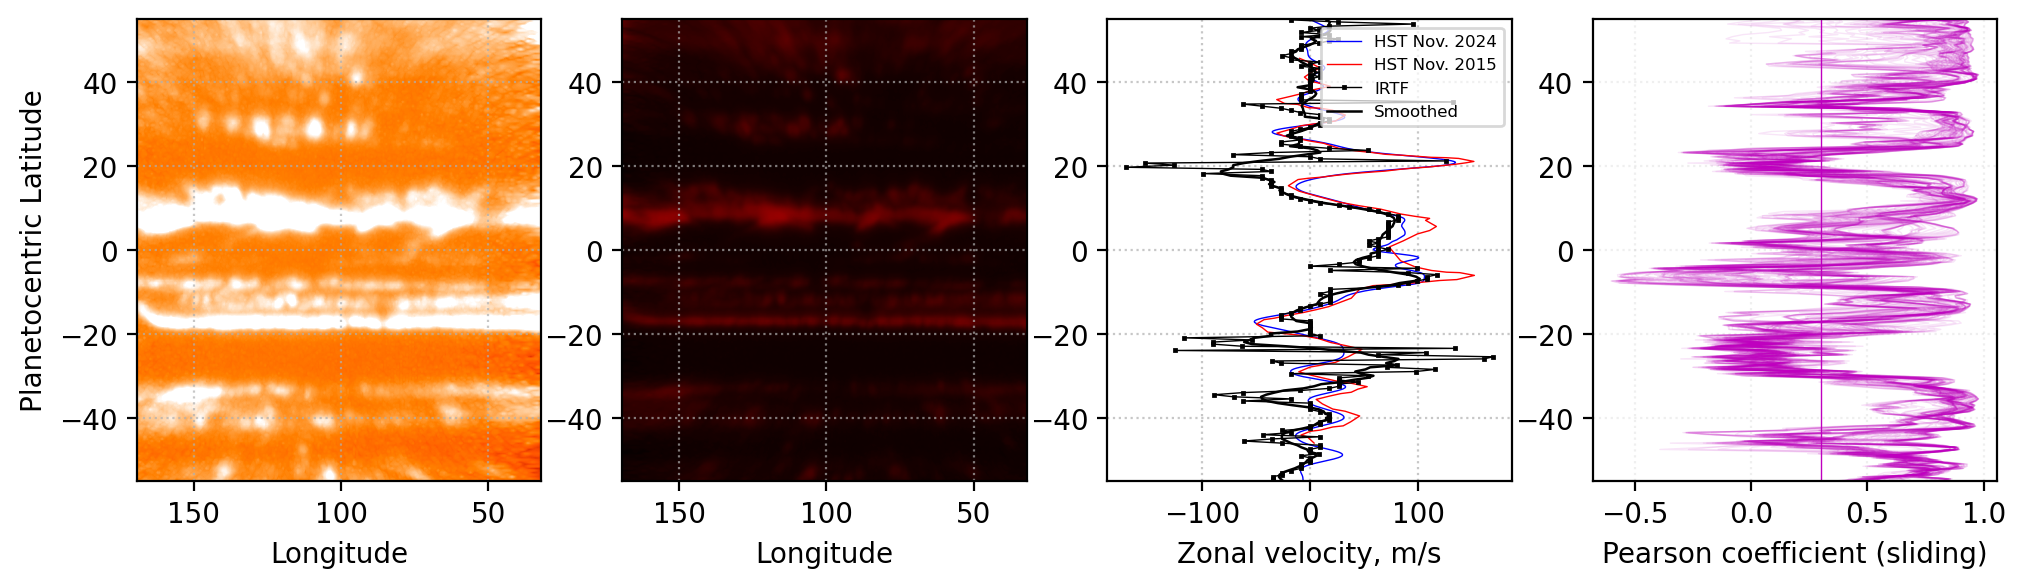

In [23]:
%matplotlib inline
fig, axs = plt.subplots(
nrows=1, ncols=4, figsize=(12, 3), dpi=200)
axs[0].contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap1, plot1_range, cmap=colo, alpha=1)
# axs[0].hlines(-7, 50, 100, ls='dashed', color='w', lw=0.75) 
axs[1].contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap2, plot2_range, cmap=colo)
# axs[1].hlines(-7, 50, 100, ls='dashed', color='w', lw=0.75) 
axs[0].grid(True, 'both', ls=':', alpha=0.7), axs[1].grid(True, 'both', ls=':', alpha=0.7)
axs[0].set_ylim(-y_lim_range, y_lim_range), axs[1].set_ylim(-y_lim_range, y_lim_range)
axs[0].invert_xaxis(), axs[1].invert_xaxis()

# axs[2].plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', lw=0.5, label='HST 2015')
axs[2].plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.5, label='HST Nov. 2024')
axs[2].plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.5, label='HST Nov. 2015')
axs[2].plot(zwp_5microns, lat_array_use, marker='s', ms=1, color='k', lw=0.5, label='IRTF')
axs[2].plot(smooth_zwp_5microns, lat_array_use, color='k', lw=0.9, label='Smoothed')
axs[2].set_xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
axs[2].set_ylim(-y_lim_range, y_lim_range)
axs[2].grid(True, 'both', ls=':', alpha=0.7)
axs[2].legend(loc='upper right', framealpha=0.75, fontsize=6)

axs[0].set_ylabel('Planetocentric Latitude')
axs[0].set_xlabel('Longitude'), axs[1].set_xlabel('Longitude')

axs[3].plot(corr_1D_coeff, lat_array_use, color='m', lw=0.5, alpha=0.1)
axs[3].set_ylim(-y_lim_range, y_lim_range)
axs[3].grid(True, 'both', ls=':', alpha=0.2)
# axs[3].set_xlabel('Correlation Strength')
axs[3].set_xlabel('Pearson coefficient (sliding)')
axs[3].vlines(0.3, -y_lim_range, y_lim_range, color='m', lw=0.5)

# axs[3].plot(intensity_mean_map1, lat_array_use, color='m', lw=0.5, label='map 1')
# axs[3].vlines(np.nanmean(intensity_mean_map1), -y_lim_range, y_lim_range, color='m', lw=0.5)
# axs[3].plot(intensity_mean_map2, lat_array_use, color='m', ls=':', lw=0.5, label='map 2')
# axs[3].vlines(np.nanmean(intensity_mean_map2), -y_lim_range, y_lim_range, color='m', ls=':')
# axs[3].set_ylim(-y_lim_range, y_lim_range)
# axs[3].set_xlim(0, np.nanmax([intensity_mean_map1, intensity_mean_map2]))
# axs[3].grid(True, 'both', ls=':', alpha=0.7)
# axs[3].set_xlabel('Pixel Intensity')
# axs[3].legend(loc='upper right', framealpha=0.75, fontsize=6)


plt.show()

In [22]:
heatmap1.shape

(180, 137)

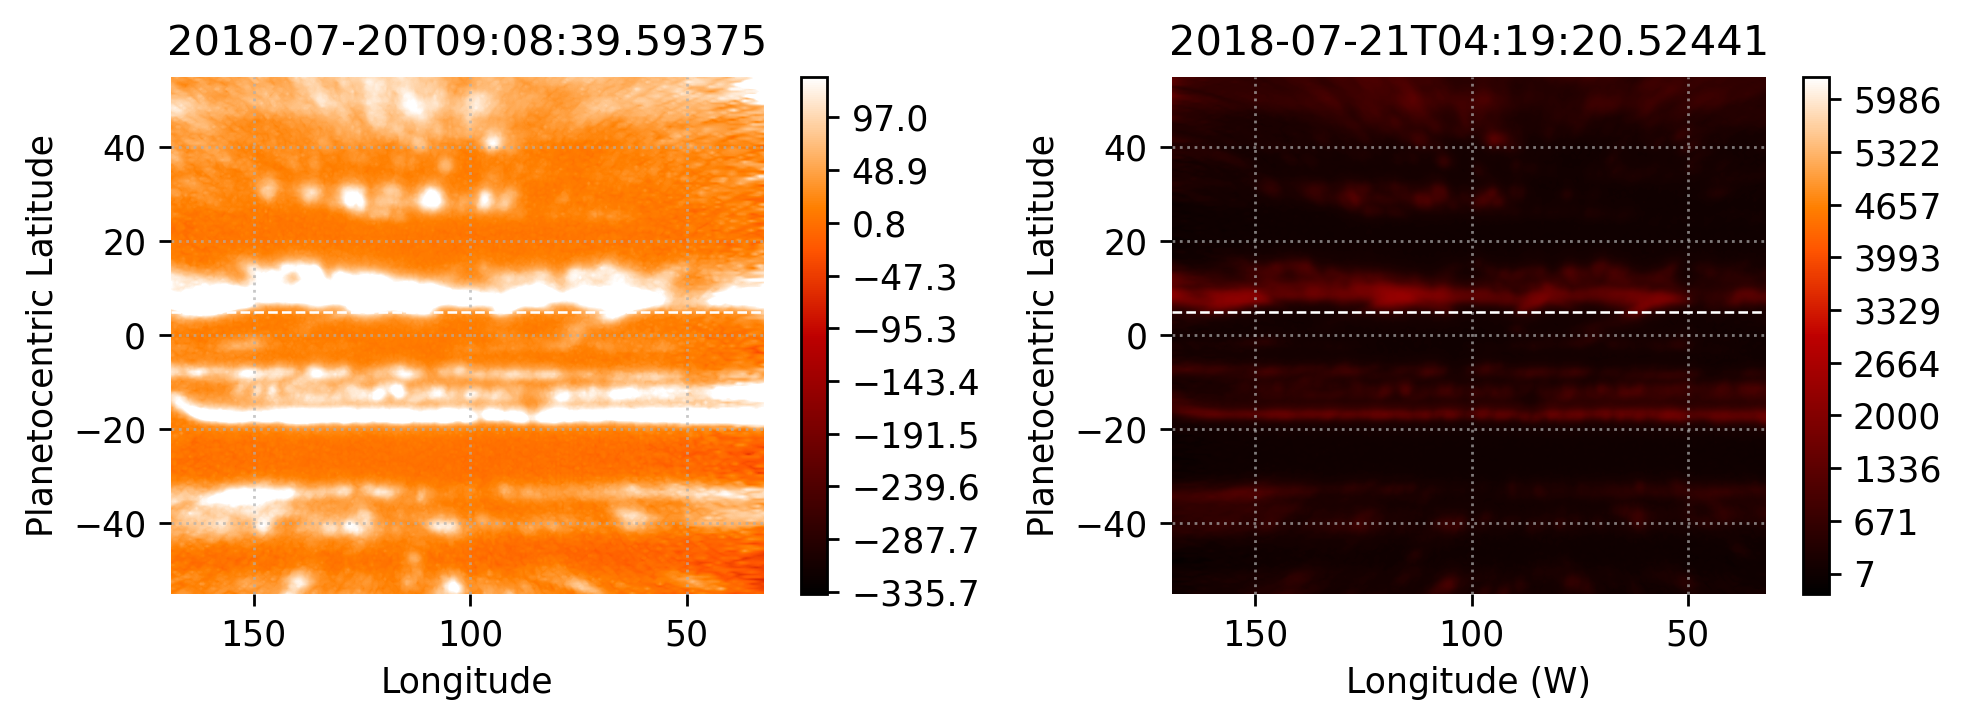

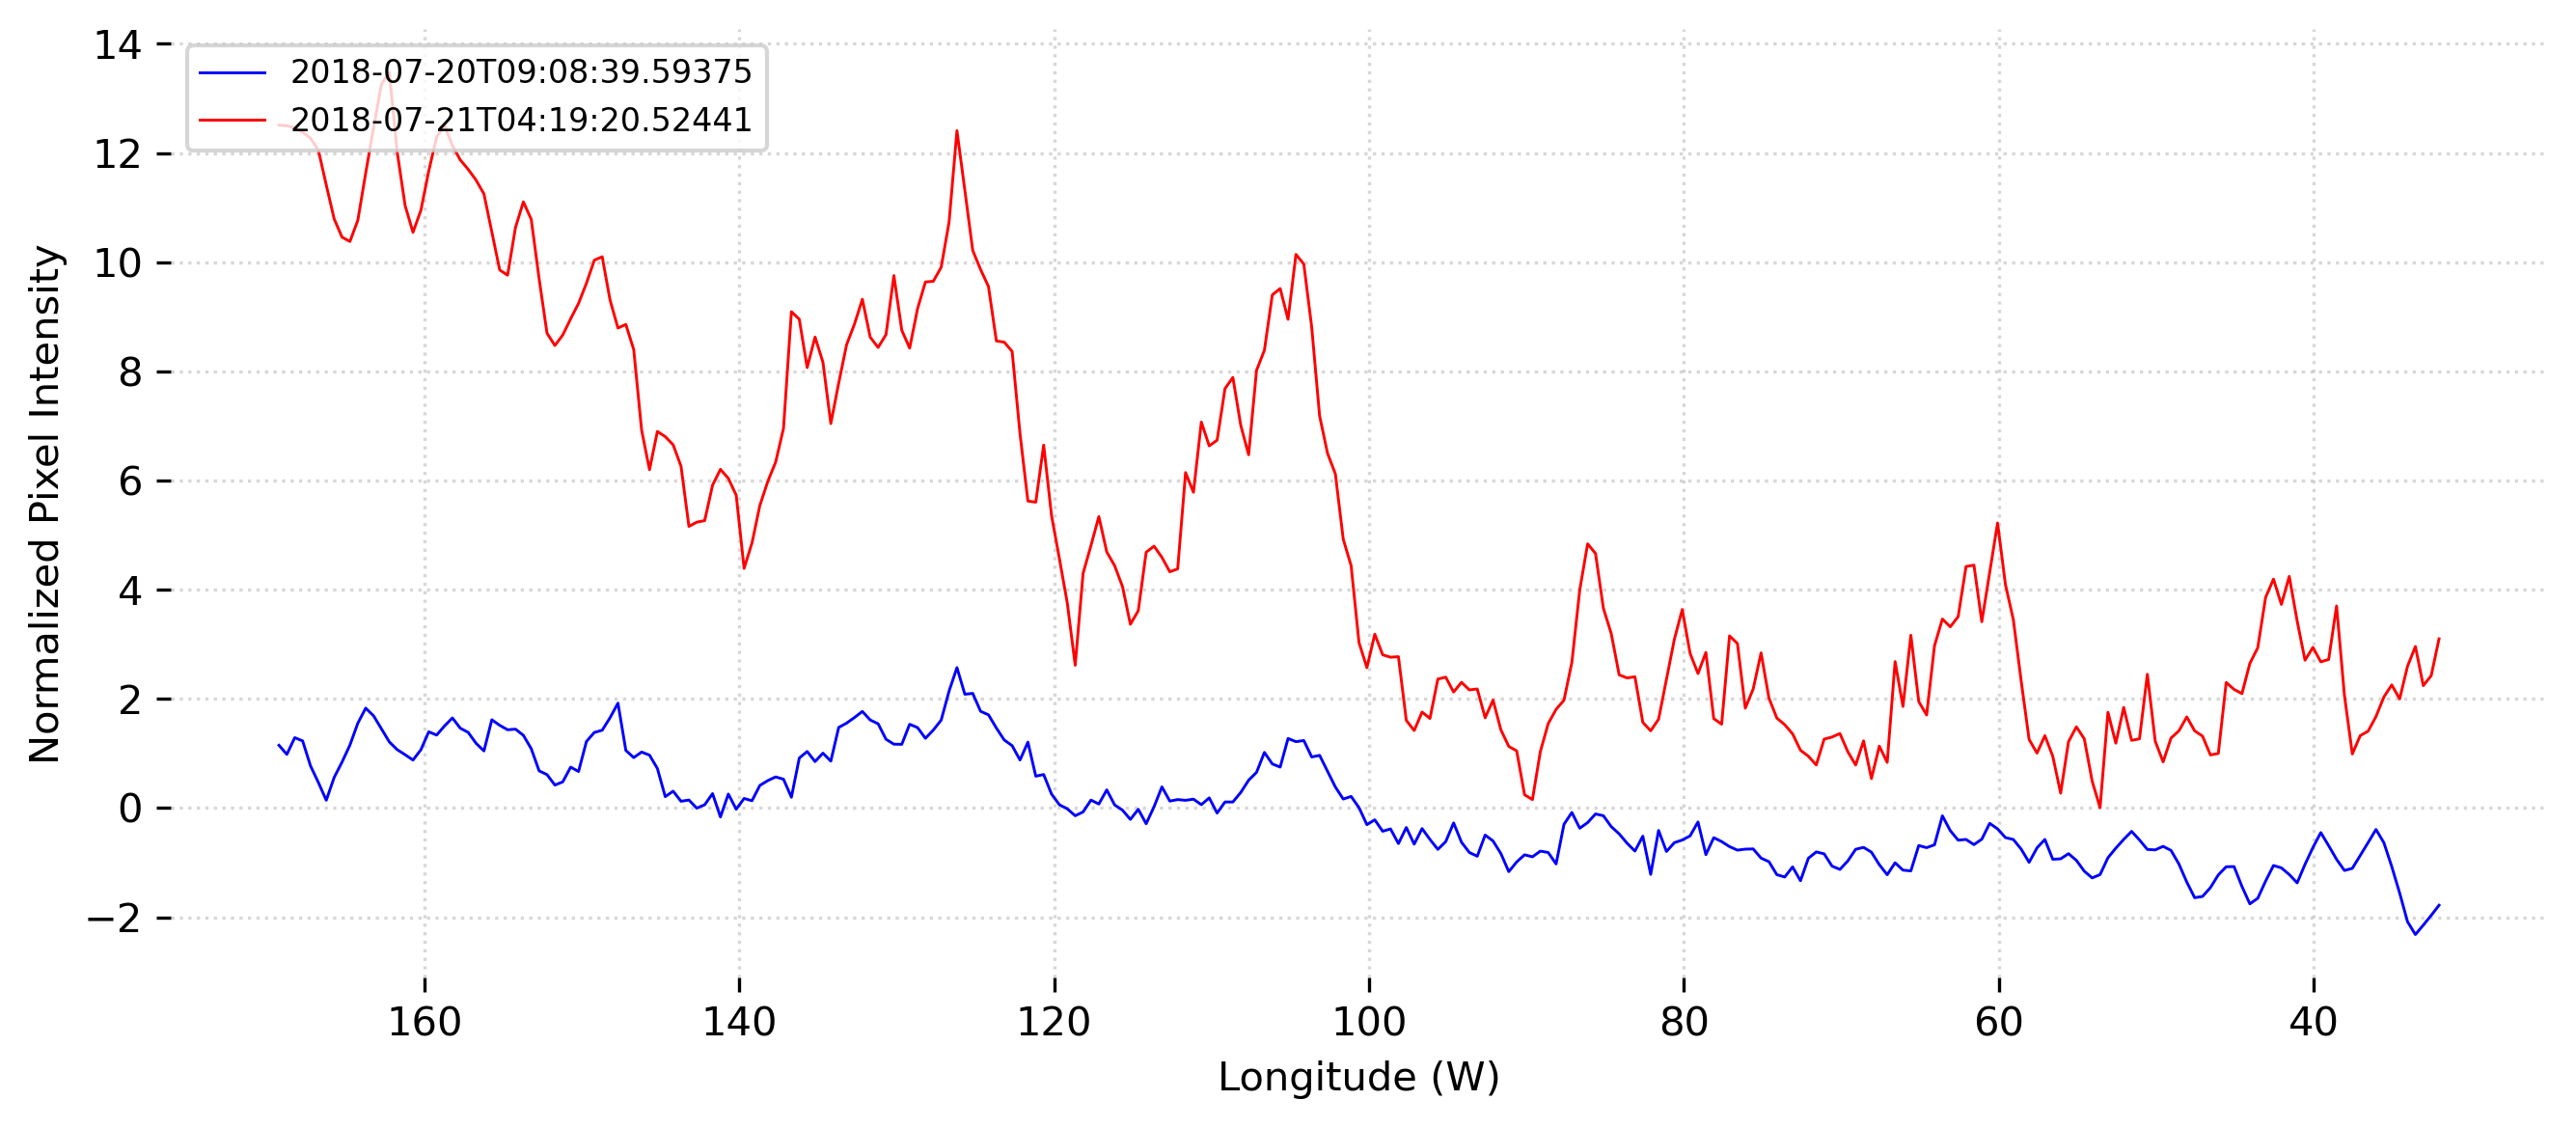

In [21]:
%matplotlib inline

test_lat = 5

plt.figure(figsize=(8, 3), dpi=250)
plt.subplot(121)
plt.contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap1, plot1_range, cmap='gist_heat')
plt.hlines(test_lat, long_array_use[margin_applied_in_func_shifted.astype(bool)][0], long_array_use[margin_applied_in_func_shifted.astype(bool)][-1], ls='dashed', color='w', lw=0.75) 
plt.grid(True, 'both', ls=':', alpha=0.7), axs[1].grid(True, 'both', ls=':', alpha=0.7)
plt.ylim(-y_lim_range, y_lim_range)
plt.gca().invert_xaxis(), plt.title(date_meta_list[test_i][0])
plt.colorbar()

plt.gca().set_frame_on(False)

plt.ylabel('Planetocentric Latitude')
plt.xlabel('Longitude'), plt.xlabel('Longitude')

plt.subplot(122)
plt.contourf(long_array_use[margin_applied_in_func_shifted.astype(bool)], lat_array_use, heatmap2, plot2_range, cmap='gist_heat')
plt.hlines(test_lat, long_array_use[margin_applied_in_func_shifted.astype(bool)][0], long_array_use[margin_applied_in_func_shifted.astype(bool)][-1], ls='dashed', color='w', lw=0.75) 
plt.grid(True, 'both', ls=':', alpha=0.7), axs[1].grid(True, 'both', ls=':', alpha=0.7)
plt.ylim(-y_lim_range, y_lim_range)
plt.gca().invert_xaxis(), plt.title(date_meta_list[test_i][1])
plt.colorbar()

plt.gca().set_frame_on(False)

plt.ylabel('Planetocentric Latitude')
plt.xlabel('Longitude (W)'), plt.xlabel('Longitude (W)')

plt.tight_layout()

# # plt.show()

# Compute mean and standard deviation of valid values (for test_lat)
f1_mean, f2_mean = np.mean(heatmap1, axis=1), np.mean(heatmap2, axis=1) # 1D arrays of means
f1_std, f2_std   = np.std(heatmap1, axis=1), np.std(heatmap2, axis=1) # 1D arrays of stds
f1_var, f2_var   = np.var(heatmap1, axis=1), np.var(heatmap2, axis=1) # 1D arrays of variances

f1f2_mean  = np.mean((heatmap1+heatmap2)/2, axis=1) # 1D arrays of means
f1f2_std   = np.std( (heatmap1+heatmap2)/2, axis=1) # 1D arrays of stds
f1f2_var   = np.var( (heatmap1+heatmap2)/2, axis=1) # 1D arrays of variances

normed_f1 = (heatmap1[90+test_lat, :] - f1_mean[90+test_lat]) / f1_std[90+test_lat]
normed_f2 = (heatmap2[90+test_lat, :] - f1_mean[90+test_lat]) / f1_std[90+test_lat]

normed_wboth_f1 = (heatmap1[90+test_lat, :] - f1f2_mean[90+test_lat]) / f1f2_std[90+test_lat]
normed_wboth_f2 = (heatmap2[90+test_lat, :] - f1f2_mean[90+test_lat]) / f1f2_std[90+test_lat]


plt.figure(figsize=(9,4), dpi=300)

# plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], heatmap1[90+test_lat, :], marker='*', lw=0.7)
# plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], heatmap2[90+test_lat, :], marker='*', color='r', lw=0.7)

plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], normed_f1, ls='solid', color='b', lw=0.7, label=date_meta_list[test_i][0])
plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], normed_f2, ls='solid', color='r', lw=0.7, label=date_meta_list[test_i][1])

# plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], normed_wboth_f1, ls=':', color='b', lw=0.7, label='normed with both f1')
# plt.plot(long_array_use[margin_applied_in_func_shifted.astype(bool)], normed_wboth_f2, ls=':', color='r', lw=0.7, label='normed with both f2')
plt.legend(loc='upper left', fontsize=8)


# plt.plot(long_array, np.roll(cmap_meta_list[1][0, 90, :], 1), color='c', lw=0.7, ls=':', alpha=0.5)
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.xlabel('Longitude (W)'), plt.ylabel('Normalized Pixel Intensity')

plt.gca().set_frame_on(False)
plt.tight_layout()


plt.show()

In [24]:
cmap_files_paths_list_51[0][0].split('.cmap')[0]+'.mu.fits.gz'

'/prvt/juno1/spex/2024aug16/images/5.10/jupiter/jc183201.mu.fits.gz'

In [25]:
print('IRTF Diffraction Limit (arcsec): ', (1.22*5.1E-6/3)*180/np.pi * 3600, '"')

IRTF Diffraction Limit (arcsec):  0.42779320815647787 "


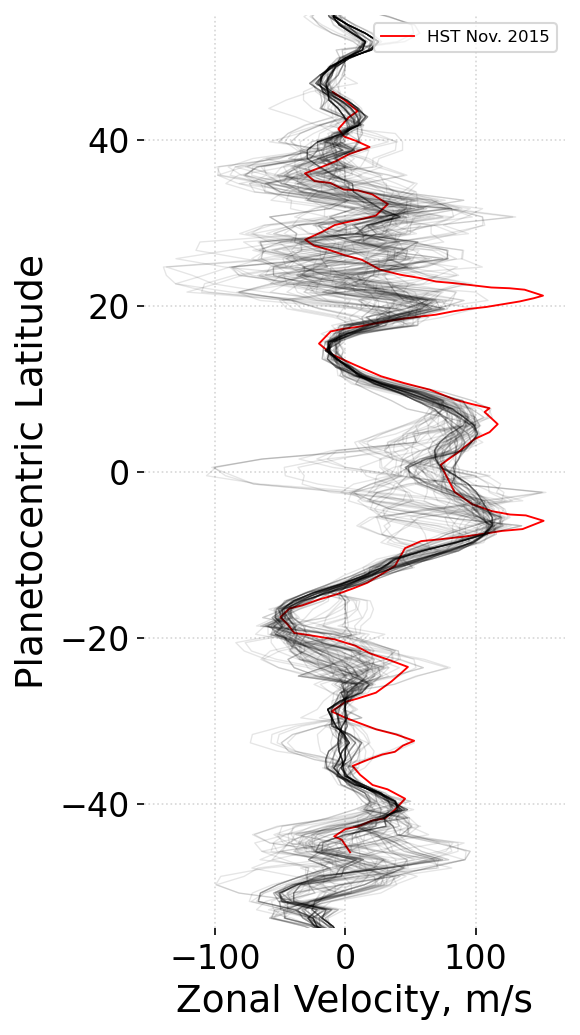

In [26]:
%matplotlib inline

plt.figure(figsize=(4,7), dpi=150)

plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.9, label='HST Nov. 2015')
for c in range(corr_1D.shape[1]):
    rough_wind_full[:, c] = -ZWP_Class.getSpeedatLat(corr_1D[:, c], lat_array_use, delta_t)
    smooth_wind_full[:, c] = ZWP_Class.getSmoothedProfile(rough_wind_full[:, c], lat_array_use, jet_width=7, poly_order=3)
    plt.plot(smooth_wind_full[:, c], lat_array_use, color='k', lw=0.65, alpha=0.1)
    plt.ylim(-critical_lat, critical_lat)

plt.ylabel('Planetocentric Latitude', size=18), plt.xlabel('Zonal Velocity, m/s', size=18)
plt.gca().set_frame_on(False)
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.xticks(fontsize=16), plt.yticks(fontsize=16)
plt.legend(loc='upper right', framealpha=0.75, fontsize=8)
plt.tight_layout()
plt.show()

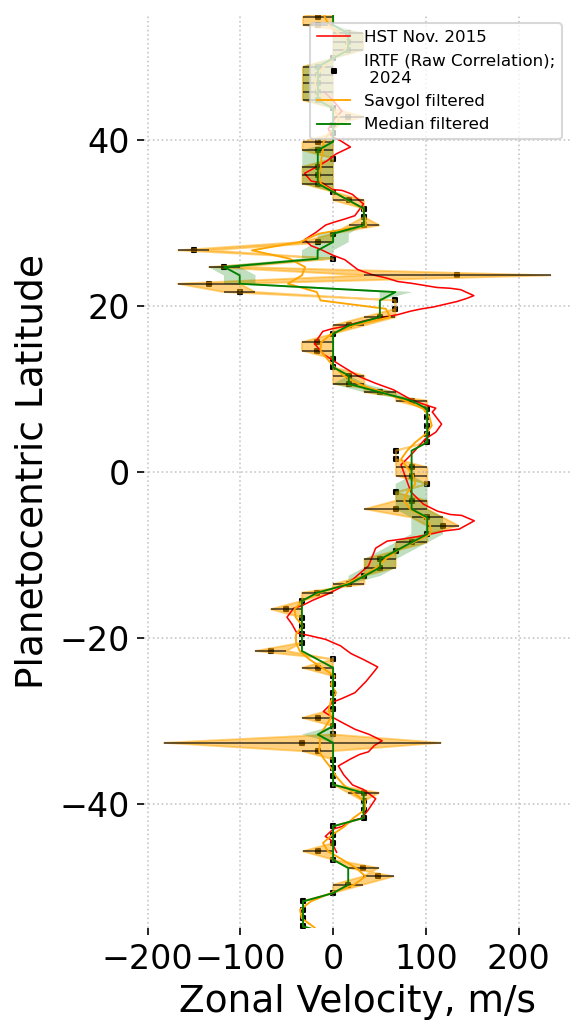

In [27]:
%matplotlib inline

plt.figure(figsize=(4,7), dpi=150)
# plt.plot(opal_nov_2024_df['FMZW'], centric_lat_HST, color='b', lw=0.75, label='HST Nov. 2024')
plt.plot(hst_wind_1D['x'], centric_lat_HST_2015, color='r', lw=0.75, label='HST Nov. 2015')

for z in range(len(zwp_5microns)):
    plt.hlines(lat_array_use[z], zwp_5microns[z]-err_velocity[z], zwp_5microns[z]+err_velocity[z], colors='k', alpha=0.75, lw=0.75)
plt.scatter(zwp_5microns, lat_array_use, marker='s', s=5, color='k', label='IRTF (Raw Correlation);\n '+str(year))

# plt.fill_betweenx(lat_array_use, smooth_zwp_5microns-smooth_err_velocity, smooth_zwp_5microns+smooth_err_velocity, lat_array_use, color='orange', lw=0.9, alpha=0.5)
plt.plot(smooth_zwp_5microns, lat_array_use, color='orange', lw=0.9, label='Savgol filtered')
plt.fill_betweenx(lat_array_use, zwp_5microns-err_velocity, zwp_5microns+err_velocity, lat_array_use, color='orange', lw=0.9, alpha=0.5)

plt.fill_betweenx(lat_array_use, medfilt_zwp_5microns-medfilt_err_velocity, medfilt_zwp_5microns+medfilt_err_velocity, lat_array_use, color='g', lw=0.1, alpha=0.25)
plt.plot(medfilt_zwp_5microns, lat_array_use, color='g', lw=0.9, label='Median filtered')

# for i in range(len(test_var_array)):
#     smooth_zwp_5microns_var = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array_use, jet_width=7, poly_order=test_var_array[i])
#     plt.plot(smooth_zwp_5microns_var, lat_array_use, lw=0.5, label='jet 7')
plt.ylabel('Planetocentric Latitude', size=18), plt.xlabel('Zonal Velocity, m/s', size=18)
plt.xticks(fontsize=16), plt.yticks(fontsize=16)
# plt.xlim(-1000, 1000)
plt.ylim(-critical_lat, critical_lat)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper right', framealpha=0.75, fontsize=8)

plt.gca().set_frame_on(False)
plt.tight_layout()
plt.show()

In [28]:
[['2025apr23', '2025apr24'],
 ['2025apr4', '2025apr5'],
 ['2025aug13', '2025aug14'],
 ['2025mar7', '2025mar8'],
 ['2025mar8', '2025mar9'],
 ['2025may6', '2025may7'],
 ['2025sep11', '2025sep12'],
 ['2025sep12','2025sep13']]

[['2025apr23', '2025apr24'],
 ['2025apr4', '2025apr5'],
 ['2025aug13', '2025aug14'],
 ['2025mar7', '2025mar8'],
 ['2025mar8', '2025mar9'],
 ['2025may6', '2025may7'],
 ['2025sep11', '2025sep12'],
 ['2025sep12', '2025sep13']]

In [29]:
HST_interp_lat_array_cent

NameError: name 'HST_interp_lat_array_cent' is not defined